In [3]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from pydantic import  BaseModel,Field
from dotenv import  load_dotenv

In [11]:
load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [15]:
## make the sentiment structured output

class SentimentResult(BaseModel):
    sentiment: str = Field(
          description="The sentiment of the user message: positive or negative"
    )

    reason: str = Field(
        description="Short reason for the sentiment"
    )


structured_llm = llm.with_structured_output(SentimentResult,method = 'json_schema')

result = structured_llm.invoke(
    "Your internet service is terrible and I am very frustrated."
)
print(result)
    

sentiment='negative' reason='frustrated with poor internet service'


In [45]:
class DiagnosisResult(BaseModel):
    problem: str = Field(
        description="The main problem described by the user"
    )

    possible_cause: str = Field(
        description="The possible cause of the problem"
    )

    recommended_action: str = Field(
          description="Recommended action or solution"
    )


diagnosis_llm = llm.with_structured_output(DiagnosisResult,method= 'json_schema')


In [31]:
## states
class State(TypedDict):
    user_message: str
    sentiment:str
    sentiment_reason: str

    problem: str

    possible_cause: str
    recommended_action: str
    final_response: str

In [18]:
def find_sentiment(state: State):

    prompt = f"""
    Analyze the sentiment of the following user message.

    The sentiment must be either:
    - positive
    - negative

    Also provide a short reason for the sentiment.

    User message:
    {state["user_message"]}
    """

    result = structured_llm.invoke(prompt)

    return {
        "sentiment": result.sentiment,
        "sentiment_reason": result.reason
    }

In [26]:
## router function

def sentiment_router(state: State):
    if state['sentiment'] == 'negative':
        return 'negative'


    return 'positive'

In [42]:
## run_diagnose node
def run_diagnosis(state: State):

    prompt = f"""
    Analyze the user's problem and provide a diagnosis.

    Return ONLY valid JSON.

    The JSON must contain exactly these fields:
    {{
        "problem": "main problem",
        "possible_cause": "possible cause",
        "recommended_action": "recommended solution or action"
    }}

    User message:
    {state["user_message"]}
    """

    result = diagnosis_llm.invoke(prompt)

    return {
        "problem": result.problem,
        "possible_cause": result.possible_cause,
        "recommended_action": result.recommended_action
    }

In [37]:
## negitive_response node

def negative_response(state: State):
    prompt = f"""
    Write a helpful and empathetic response to the user.

    The user is frustrated, so acknowledge their frustration.

    Use the diagnosis information below to provide a clear
    and solution-oriented response.

    User message: {state['user_message']}

    Problem: {state['problem']}

    Possible cause: {state['possible_cause']}

    Recommended action: {state['recommended_action']}


     Give ONLY the final response to the user.
    Do not mention that you are an AI.
    Do not mention internal diagnosis or workflow.
    """

    result = llm.invoke(prompt)

    return{
        'final_response': result.content
    }









In [38]:
## positive response noode
def positive_response(state: State):

    prompt = f"""
    Respond to the user in a friendly and positive way.

    User message: {state['user_message']}


    Give ONLY the response that should be shown to the user.
    Keep it natural and helpful.
    """


    result = llm.invoke(prompt)


    return{
        'final_response': result.content
    }

In [39]:
graph = StateGraph(State)

graph.add_node('find_sentiment',find_sentiment)

graph.add_node('run_diagnosis',run_diagnosis)

graph.add_node('negative_response',negative_response)

graph.add_node('positive_response',positive_response)


graph.add_edge(START,'find_sentiment')

## conditional routing after sentiment

graph.add_conditional_edges(
    'find_sentiment',
    sentiment_router,
    {
        'negative': 'run_diagnosis',
        'positive': 'positive_response'
    }
)

graph.add_edge(
    'run_diagnosis',
    'negative_response'
)


graph.add_edge(
    'negative_response',END
)

graph.add_edge(
    'positive_response',END
)

workflow =  graph.compile()

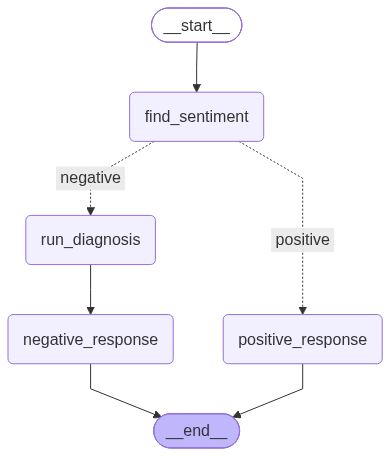

In [40]:
workflow

In [49]:
result =  workflow.invoke({
 "user_message": "Your internet service has been terrible for the past two days. I’ve contacted support multiple times, but nobody has fixed the issue. This is extremely frustrating."
}
)

result

{'user_message': 'Your internet service has been terrible for the past two days. I’ve contacted support multiple times, but nobody has fixed the issue. This is extremely frustrating.',
 'sentiment': 'negative',
 'sentiment_reason': 'frustration due to unresolved internet issues',
 'problem': 'Internet service has been terrible for the past two days and support has not resolved the issue',
 'possible_cause': 'A local network outage, ISP equipment failure, or a malfunctioning router/modem could be causing the persistent connectivity problems',
 'recommended_action': 'Restart your router and modem, run a speed test to confirm the issue, check for any ISP outage notifications, and if the problem persists, request a technician visit or consider switching providers if the service remains unreliable',
 'final_response': 'I’m really sorry you’ve been dealing with this for so long—having a bad internet connection is incredibly frustrating, especially when it feels like nobody’s been able to fix